## Connecting SQL to Jupiter

In [1]:
pip install pandas sqlalchemy psycopg2-binary

Note: you may need to restart the kernel to use updated packages.


In [2]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

connection_url = URL.create(
    "postgresql+psycopg2",
    username="postgres",
    password="G1g1g2g6z()&$",
    host="127.0.0.1",
    port=5432,
    database="Pet_Adoption"
)

engine = create_engine(connection_url)

with engine.connect() as connection:
    print("Connected!")

Connected!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_sql(
    "Select * From pet_adoption_data LIMIT 12;",
    engine
)

df

,pet_id,pet_type,breed,age_months,color,pet_size,weight_kg,vaccinated,health_condition,time_in_shelter_days,adoption_fee,previous_owner,adoption_liklihood
0,500,Bird,Parakeet,131,Orange,Large,5.04,1,0,27,140.0,0,0
1,501,Rabbit,Rabbit,73,White,Large,16.09,0,0,8,235.0,0,0
2,502,Dog,Golden Retriever,136,Orange,Medium,2.08,0,0,85,385.0,0,0
3,503,Bird,Parakeet,97,White,Small,3.34,0,0,61,217.0,1,0
4,504,Rabbit,Rabbit,123,Gray,Large,20.50,0,0,28,14.0,1,0
5,505,Dog,Labrador,70,Brown,Large,20.99,0,0,87,301.0,1,0
6,506,Bird,Parakeet,169,Brown,Small,10.90,1,0,70,440.0,1,0
7,507,Cat,Siamese,13,Orange,Large,7.25,1,0,3,137.0,0,1
8,508,Bird,Parakeet,49,Brown,Medium,24.60,1,1,69,405.0,0,0
9,509,Bird,Parakeet,60,Gray,Large,7.30,0,0,73,231.0,1,0


In [4]:
df.head()

,pet_id,pet_type,breed,age_months,color,pet_size,weight_kg,vaccinated,health_condition,time_in_shelter_days,adoption_fee,previous_owner,adoption_liklihood
0,500,Bird,Parakeet,131,Orange,Large,5.04,1,0,27,140.0,0,0
1,501,Rabbit,Rabbit,73,White,Large,16.09,0,0,8,235.0,0,0
2,502,Dog,Golden Retriever,136,Orange,Medium,2.08,0,0,85,385.0,0,0
3,503,Bird,Parakeet,97,White,Small,3.34,0,0,61,217.0,1,0
4,504,Rabbit,Rabbit,123,Gray,Large,20.50,0,0,28,14.0,1,0


In [5]:
df.shape

(12, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pet_id                12 non-null     object 
 1   pet_type              12 non-null     object 
 2   breed                 12 non-null     object 
 3   age_months            12 non-null     int64  
 4   color                 12 non-null     object 
 5   pet_size              12 non-null     object 
 6   weight_kg             12 non-null     float64
 7   vaccinated            12 non-null     int64  
 8   health_condition      12 non-null     int64  
 9   time_in_shelter_days  12 non-null     int64  
 10  adoption_fee          12 non-null     float64
 11  previous_owner        12 non-null     int64  
 12  adoption_liklihood    12 non-null     int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 1.3+ KB


In [7]:
df.isnull().sum()

pet_id                  0
pet_type                0
breed                   0
age_months              0
color                   0
pet_size                0
weight_kg               0
vaccinated              0
health_condition        0
time_in_shelter_days    0
adoption_fee            0
previous_owner          0
adoption_liklihood      0
dtype: int64

## 1. What does the distribution of pet ages look like? 

In [8]:
df["age_months"].describe()

count     12.000000
mean      88.000000
std       51.479917
min        5.000000
25%       57.250000
50%       85.000000
75%      130.250000
max      169.000000
Name: age_months, dtype: float64

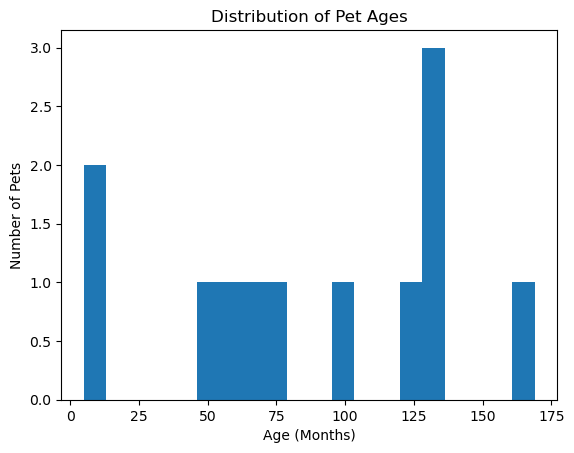

In [9]:
df["age_months"].plot(kind="hist", bins=20)

plt.xlabel("Age (Months)")
plt.ylabel("Number of Pets")
plt.title("Distribution of Pet Ages")
plt.show()

## 2. Is pet age related to time spent in the shelter?

In [10]:
df[["age_months", "time_in_shelter_days"]].corr()

,age_months,time_in_shelter_days
age_months,1.000000,0.062158
time_in_shelter_days,0.062158,1.000000


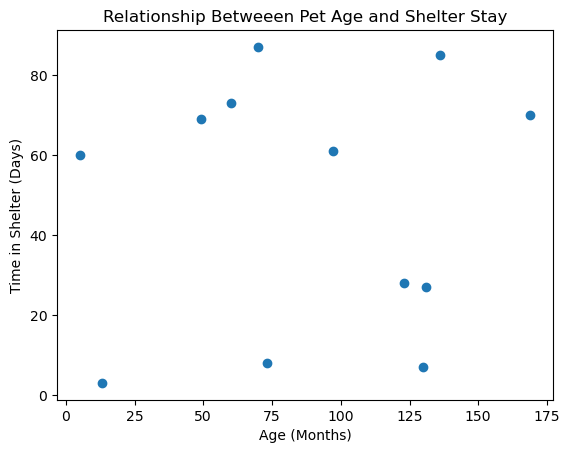

In [11]:
plt.scatter(
    df["age_months"],
    df["time_in_shelter_days"]
)

plt.xlabel("Age (Months)")
plt.ylabel("Time in Shelter (Days)")
plt.title("Relationship Betweeen Pet Age and Shelter Stay")
plt.show()

## 3. Does weight vary according to pet size?

In [12]:
df.groupby("pet_size")["weight_kg"].describe()

,count,mean,std,min,25%,50%,75%,max
pet_size,,,,,,,,
Large,7.0,13.412857,6.723064,5.04,7.275,16.09,18.61,20.99
Medium,2.0,13.340000,15.924045,2.08,7.710,13.34,18.97,24.60
Small,3.0,14.440000,13.230102,3.34,7.120,10.90,19.99,29.08


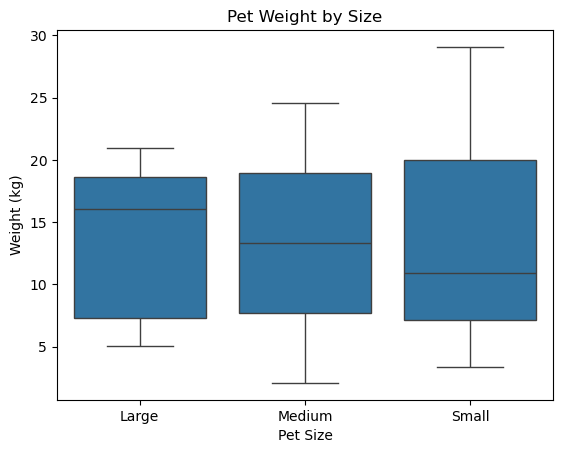

In [13]:
import seaborn as sns

sns.boxplot(
    data = df,
    x = "pet_size",
    y = "weight_kg"
)

plt.xlabel("Pet Size")
plt.ylabel("Weight (kg)")
plt.title("Pet Weight by Size")
plt.show()

## 4. Are numeric pet characteristics correlated with one another?

In [14]:
numeric_cols = [
    "age_months",
    "weight_kg",
    "time_in_shelter_days",
    "adoption_fee"
]

correlation = df[numeric_cols].corr()

correlation

,age_months,weight_kg,time_in_shelter_days,adoption_fee
age_months,1.000000,-0.413491,0.062158,-0.163989
weight_kg,-0.413491,1.000000,0.009160,0.225968
time_in_shelter_days,0.062158,0.009160,1.000000,0.700898
adoption_fee,-0.163989,0.225968,0.700898,1.000000


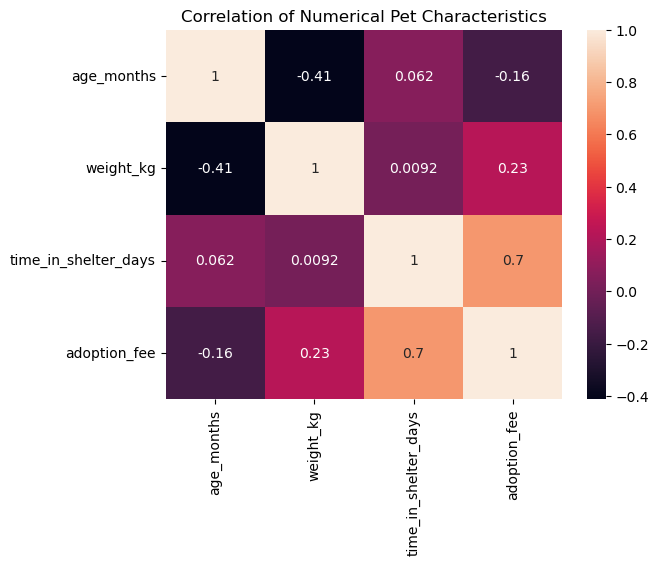

In [15]:
sns.heatmap(
    correlation,
    annot = True
)

plt.title("Correlation of Numerical Pet Characteristics")
plt.show()

## 5. How does adoption likelihood vary with pet age?

In [19]:
df.groupby("adoption_liklihood")["age_months"].describe()

,count,mean,std,min,25%,50%,75%,max
adoption_liklihood,,,,,,,,
0,10.0,103.8,39.639486,49.0,70.75,110.0,130.75,169.0
1,2.0,9.0,5.656854,5.0,7.00,9.0,11.00,13.0


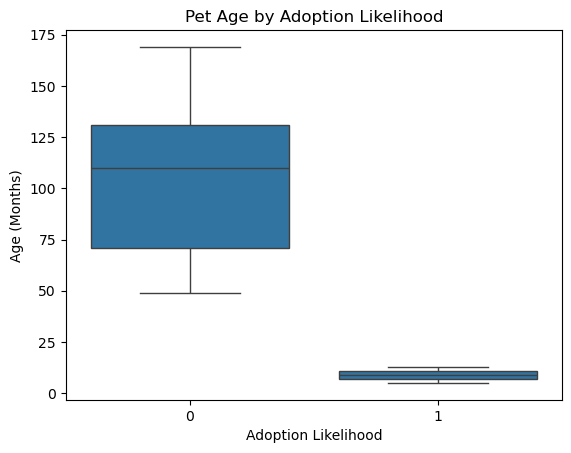

In [22]:
sns.boxplot(
    data = df,
    x = "adoption_liklihood",
    y = "age_months"
)

plt.xlabel("Adoption Likelihood")
plt.ylabel("Age (Months)")
plt.title("Pet Age by Adoption Likelihood")
plt.show()

## 6. Is adoption likelihood associated with health condition?

In [24]:
health_adoption = pd.crosstab(
    df["health_condition"],
    df["adoption_liklihood"],
    normalize = "index"
)

health_adoption

adoption_liklihood,0,1
health_condition,,
0,0.818182,0.181818
1,1.000000,0.000000


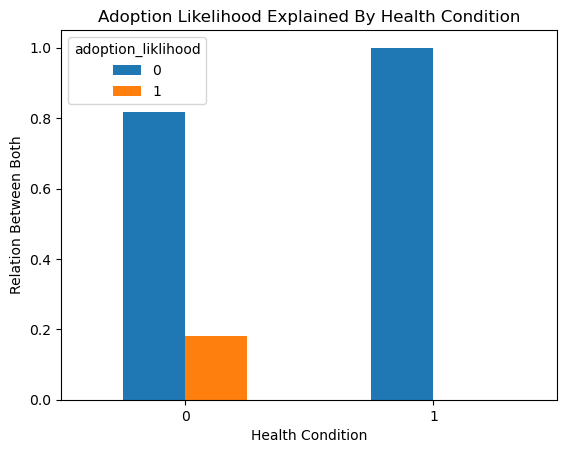

In [28]:
health_adoption.plot(kind = "bar")

plt.xlabel("Health Condition")
plt.ylabel("Relation Between Both")
plt.title("Adoption Likelihood Explained By Health Condition")
plt.xticks(rotation = 0)
plt.show()

## 7. Which pet characteristics appear most different between adopted pets and those not adopted?

In [29]:
df.groupby("adoption_liklihood")[
    [
        "age_months",
        "weight_kg",
        "time_in_shelter_days",
        "adoption_fee"
    ]
    ].mean()

,age_months,weight_kg,time_in_shelter_days,adoption_fee
adoption_liklihood,,,,
0,103.8,12.756,51.5,245.6
1,9.0,18.165,31.5,299.5
